In [1]:
%matplotlib inline
#import skmob
import pandas as pd
#import skmob.measures.individual as ind_measure
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

# Import intra-package scripts
import utils.helper_func as helper_func
import utils.GP as GP
import mobileDataToolkit.analysis as analysis
import mobileDataToolkit.preprocessing as preprocessing
import mobileDataToolkit.methods as methods
import mobileDataToolkit.metrics as metrics

In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [3]:
import skmob

## Reading Data

In [4]:
file_path = "C:\\Users\\ekino\\OneDrive - UW\\GPR\\Data\\all_obs_preprocessed.csv"

d1 = preprocessing.dp_MultiTrip(file_path, 8765765)
d1.chooseUser(d1.data.user_ID.unique()[8])

In [5]:
d1.data.columns

Index(['unix_start_t', 'user_ID', 'mark_1', 'orig_lat', 'orig_long',
       'orig_unc'],
      dtype='object')

## Adding "DateTime" column, subsetting by a timeframe

In [6]:
d1.add_DateTime()

d1.subsetByTime('01/18/2020 00:00', '02/07/2020 00:00')

d1.Multi_Trip_Preprocess()

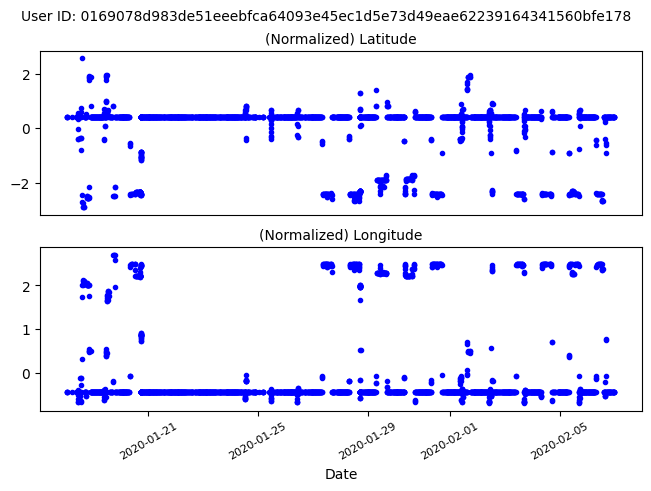

In [7]:
methods.mobVisualize(d1.data)

In [8]:
d1.data.columns

Index(['level_0', 'index', 'unix_start_t', 'user_ID', 'mark_1', 'orig_lat',
       'orig_long', 'orig_unc', 'Date_Time', 'Day of Week', 'Year', 'Month',
       'Day', 'Week', 'Hour', 'Week_of_Month', 'norm_lat', 'norm_long',
       'unix_start_t_min', 'sec_after_midnight', 'Holiday', 'weekend',
       'AM_peak', 'PM_peak', 'day_0', 'day_1', 'day_2', 'day_3', 'day_4',
       'day_5', 'day_6', 'week_1', 'week_3', 'week_4', 'week_5', 'month_1',
       'month_2'],
      dtype='object')

#### Add distance and velocity columns, determine home location

In [9]:
helper_func.addDist(d1.data)
helper_func.addVel(d1.data)
home_lat, home_lon = methods.homeLoc(d1.data)

In [10]:
d1.data['vel'].describe()

count    2494.000000
mean        0.780743
std         6.059358
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000857
max       240.619269
Name: vel, dtype: float64

In [11]:
d1.data['dist'].describe()

count    2494.000000
mean      122.563620
std       683.006261
min         0.000000
25%         0.000000
50%         0.000000
75%         0.683316
max      7724.828901
Name: dist, dtype: float64

## Further Preprocessing: Filtering, compression, stay location detection, and stay location clustering

In [12]:
import skmob.preprocessing.detection

In [13]:
%%time
tdf = skmob.TrajDataFrame(d1.data, latitude='orig_lat', longitude='orig_long', datetime='Date_Time')
f_tdf = skmob.preprocessing.filtering.filter(tdf, max_speed_kmh=400, include_loops=True)
fc_tdf = skmob.preprocessing.compression.compress(f_tdf, spatial_radius_km=0.1) # vary the spatial radius to see how prediction changes
fcs_tdf = skmob.preprocessing.detection.stay_locations(fc_tdf)

Wall time: 366 ms


In [14]:
n_deleted_points = len(tdf) - len(f_tdf) # number of deleted points during filtering
print(n_deleted_points)

10


In [15]:
n_deleted_points = len(f_tdf) - len(fc_tdf) # number of deleted points during compression
n_deleted_points / len(d1.data)

0.8917401764234162

In [16]:
m = fcs_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcs_tdf.plot_stops(map_f=m)

In [17]:
# navigate to 'CIS Project Big Data 2021/scikit-mobility' first
import skmob.preprocessing.clustering

In [18]:
fcsc_tdf = skmob.preprocessing.clustering.cluster(fcs_tdf, cluster_radius_km=0.2, min_samples=1)
m2 = fcsc_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcsc_tdf.plot_stops(map_f=m2)

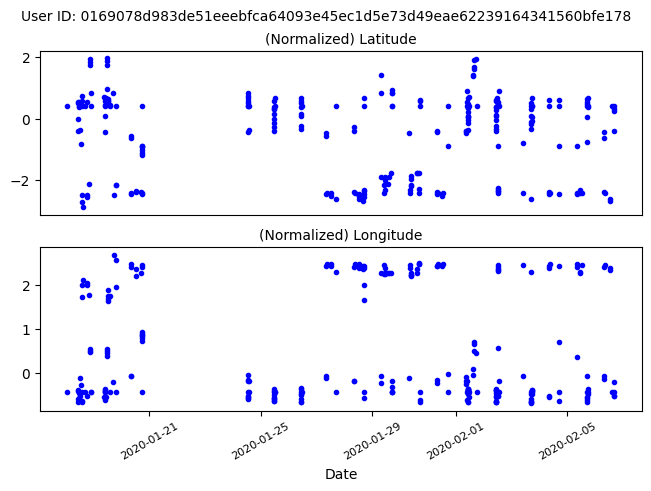

In [19]:
# This is what the data we will predict with now looks like
methods.mobVisualize(fc_tdf)

## Train/Test Split

In [20]:
#d1.Multi_Trip_TrainTestSplit('2020-02-01 00:00', '2020-02-07 00:00')
train, test, X_train, y_train, X_test, y_test, date_train, date_test = methods.Multi_Trip_TrainTestSplit(fc_tdf, '2020-02-01 00:00', '2020-02-07 00:00')

### Normalize data

In [21]:
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()
scaler3 = MinMaxScaler()

unix_train = torch.tensor(scaler1.fit_transform(X_train[:,0].reshape(-1,1))).float()
secs_train = torch.tensor(scaler2.fit_transform(X_train[:,1].reshape(-1,1))).float()
unix_test = torch.tensor(scaler1.transform(X_test[:,0].reshape(-1,1))).float()
secs_test = torch.tensor(scaler2.transform(X_test[:,1].reshape(-1,1))).float()

X_train = torch.cat([unix_train, secs_train, X_train[:, 2::]], -1).float()
X_test = torch.cat([unix_test, secs_test, X_test[:, 2::]], -1).float()

y_train = torch.tensor(scaler3.fit_transform(y_train)).float()
y_test = torch.tensor(scaler3.transform(y_test)).float()

n_dims = X_train.shape[1]

## Temporal Occupancy

In [23]:
test_TO = analysis.tempOcp(test, bin_len=20)
test_TO

0.11979166666666667

## Defining the model

In [24]:
model = GP.MTGPRegressor(X_train, y_train, ScaleKernel( RQ(ard_num_dims = n_dims) * PER(active_dims=torch.tensor([0]))) + ScaleKernel(RQ(ard_num_dims = n_dims) * PER(active_dims=torch.tensor([0]))))

### Initialize the kernel's lengthscale to 10 minutes

In [25]:
scaled_lengthscale = scaler1.transform(torch.tensor(600).reshape(-1,1)).item()
scaled_period_1 = scaler1.transform(torch.tensor(1440).reshape(-1,1))
scaled_period_2 = scaler1.transform(torch.tensor(10080).reshape(-1,1))
initializations = np.ones(15)
initializations = np.insert(initializations, 0, [scaled_lengthscale, scaled_lengthscale])

#model.covar_module.data_covar_module.lengthscale = initializations
#model.covar_module.data_covar_module.lengthscale

try:
    n_comp = len([m for m in model.covar_module.data_covar_module.kernels])
    for i in range(n_comp):
        model.covar_module.data_covar_module.kernels[i].outputscale = (1 / n_comp)
except AttributeError:
    n_comp = 1

model.covar_module.data_covar_module.kernels[0].base_kernel.kernels[0].lengthscale = initializations
model.covar_module.data_covar_module.kernels[1].base_kernel.kernels[0].lengthscale = initializations
model.covar_module.data_covar_module.kernels[0].base_kernel.kernels[1].period_length = scaled_period_1
model.covar_module.data_covar_module.kernels[1].base_kernel.kernels[1].period_length = scaled_period_2

In [26]:
%%time
ls, mll = GP.training(model, X_train, y_train)

 37%|███████████████████▏                                | 74/200 [00:01<00:03, 37.02it/s, Loss=-0.809, noise=0.000156]

Wall time: 2 s


In [27]:
with torch.no_grad():
    log_ll = mll(model(X_train), y_train) * X_train.shape[0]
            
N = X_train.shape[0]
m = sum(p.numel() for p in model.hyperparameters())
bic = -2 * log_ll + m * np.log(N)

In [28]:
predictions, mean = model.predict(X_test)

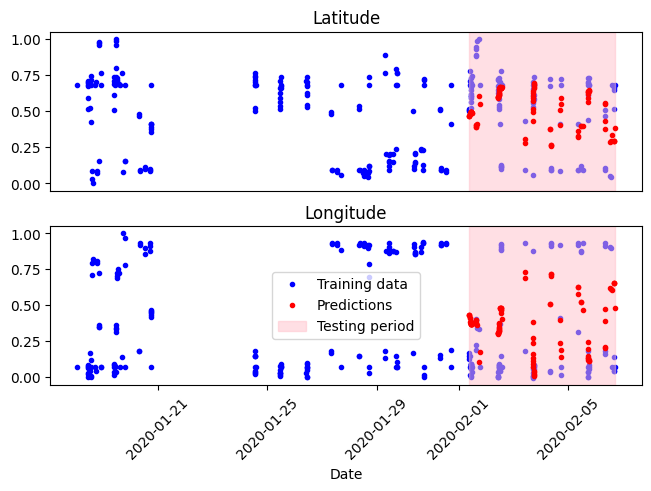

In [29]:
model.plot_preds(mean, date_train, date_test, y_train, y_test)

In [30]:
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

### SimpleExpSmoothing
`smoothing_level = 0.1`

In [67]:
lat = pd.Series(y_train[:,0].tolist(), date_train)
lat_t = pd.Series(y_test[:,0].tolist(), date_test)
lat_t.index[0]

Timestamp('2020-02-01 19:45:06')

In [73]:
dates2 = pd.to_datetime(date_test, infer_datetime_format=True)
lat_t = pd.Series(y_test[:,0].tolist(), dates2)
lat_t.index[0]

Timestamp('2020-02-01 19:45:06')

In [70]:
lon = pd.Series(y_train[:,1].tolist(), date_train)
lon_t = pd.Series(y_test[:,1].tolist(), date_test)

C:\Users\stlp\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


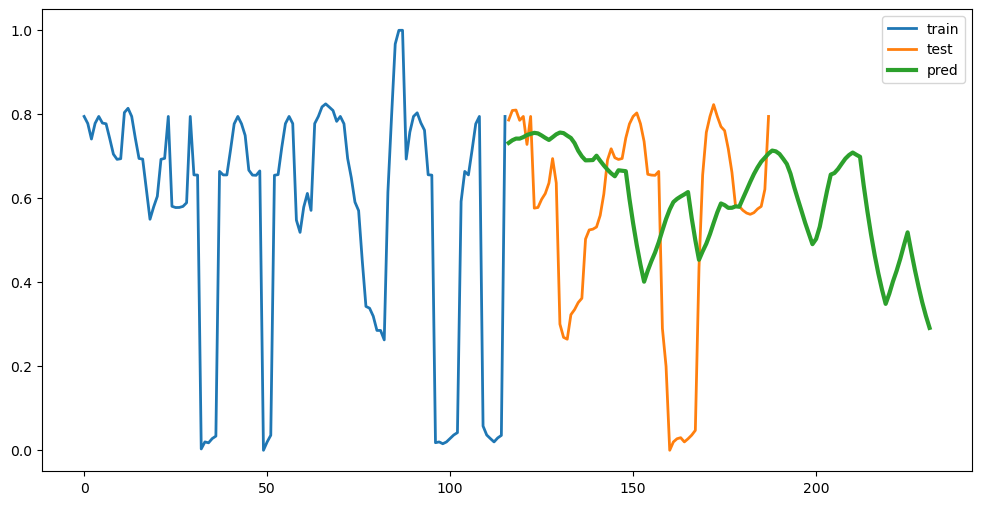

NameError: name 'ts_log_mov_diff' is not defined

In [76]:
smoothing_level = 0.1
ses = SimpleExpSmoothing(lat, initialization_method="heuristic").fit(smoothing_level=smoothing_level, optimized=True)
pred = ses.predict(start=lat.index[0], end=lat.index[-1])
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(range(len(lat)), lat, label='train', linewidth=2)
plt.plot(range(len(lat), len(lat)+len(lat_t)), lat_t, label='test', linewidth=2)
plt.plot(range(len(lat), len(lat)+len(pred)), pred, label='pred', linewidth=3)
plt.legend()
plt.show()

for k, v in metrics.evaluate(lat_t, pred, ts_log_mov_diff).items():
    print('%s %.3f' % (k, v))

### Short Gap Simulation Design
* **Assumption**: MCAR (will remove points randomly)
* Use trip data only (include trips from the past)
* Divide each trip into X-min intervals
    + Sensitivity Analysis
        - Try 1, 5, 10, 15, 30-min intervals
* Introduce sparsity at 10% intervals
    + i.e., first remove 10% of the X-min intervals, then 20%, etc.
        - Repeat process 10 times at each q to allow for different portions of the data to be removed
 

In [ ]:
tau = 5 # bin length
sparsity = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for i in range(10): # Cross-validation
    ### code below
    
    ###
    return  # output?